<a href="https://colab.research.google.com/github/jahidurmahim/Machine_Learning_Laboratory/blob/main/Credit_score_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Section 1 — Library Import & Setup

Block 1.1 — Data Libraries

In [61]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

Dataset Loading & Inspection

In [62]:
df=pd.read_csv('/train.csv')

/tmp/ipykernel_30104/181053272.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/train.csv')


In [63]:
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 100,000 rows × 28 columns


In [64]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [66]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [67]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Dropped. New shape: {df.shape}")

Duplicate rows: 0


In [68]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


In [69]:
print("\nMissing Values Summary:")
print("-----------------------")
for col in df.columns:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        missing_percentage = (missing_count / len(df)) * 100
        print(f"Column '{col}': {missing_count} missing values ({missing_percentage:.2f}%)")
print("-----------------------")


Missing Values Summary:
-----------------------
Column 'Name': 9985 missing values (9.98%)
Column 'Monthly_Inhand_Salary': 15002 missing values (15.00%)
Column 'Type_of_Loan': 11408 missing values (11.41%)
Column 'Num_of_Delayed_Payment': 7002 missing values (7.00%)
Column 'Num_Credit_Inquiries': 1965 missing values (1.97%)
Column 'Credit_History_Age': 9030 missing values (9.03%)
Column 'Amount_invested_monthly': 4479 missing values (4.48%)
Column 'Monthly_Balance': 1200 missing values (1.20%)
-----------------------


Block 2.7 — Target Variable Analysis

Standard  : 53,174  (53.2%)
Poor      : 28,998  (29.0%)
Good      : 17,828  (17.8%)


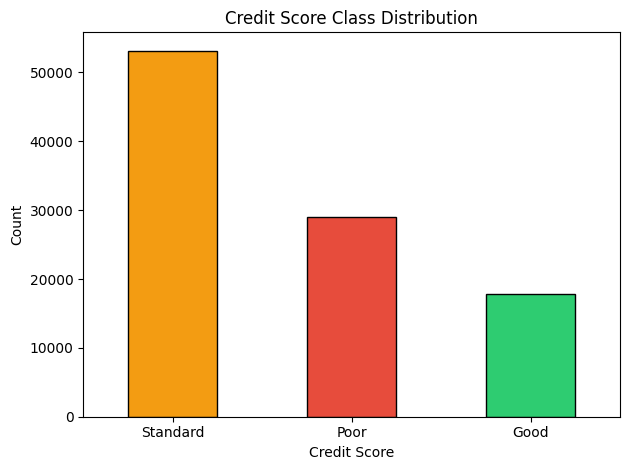

In [70]:
counts = df['Credit_Score'].value_counts()
pct = df['Credit_Score'].value_counts(normalize=True) * 100

for label in counts.index:
    print(f"{label:10}: {counts[label]:6,}  ({pct[label]:.1f}%)")

counts.plot(kind='bar', color=['#f39c12','#e74c3c','#2ecc71'], edgecolor='black')
plt.title('Credit Score Class Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Section 3 — Data Cleaning & Preprocessing

Block 3.1 — Drop Irrelevant Columns

In [71]:
df.drop(columns=['ID', 'Customer_ID', 'SSN', 'Name', 'Month', 'Type_of_Loan'], inplace=True)
print(f'Remaining columns: {df.shape[1]}')
print(df.columns.tolist())

Remaining columns: 22
['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


In [72]:
print("Shape:", df.shape)
print("\nColumn Names:")
for col in df.columns:
    print(col)

Shape: (100000, 22)

Column Names:
Age
Occupation
Annual_Income
Monthly_Inhand_Salary
Num_Bank_Accounts
Num_Credit_Card
Interest_Rate
Num_of_Loan
Delay_from_due_date
Num_of_Delayed_Payment
Changed_Credit_Limit
Num_Credit_Inquiries
Credit_Mix
Outstanding_Debt
Credit_Utilization_Ratio
Credit_History_Age
Payment_of_Min_Amount
Total_EMI_per_month
Amount_invested_monthly
Payment_Behaviour
Monthly_Balance
Credit_Score


Block 3.2 — Fix Corrupted Numeric Columns

In [73]:
cols_to_fix = [
    'Annual_Income', 'Outstanding_Debt', 'Num_of_Loan',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Amount_invested_monthly'
]
for col in cols_to_fix:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True),
        errors='coerce'
    )

# Monthly_Balance has mixed types — fix separately
df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce')

print('Columns fixed:', cols_to_fix + ['Monthly_Balance'])
print('Sample Annual_Income:', df['Annual_Income'].dropna().head(3).tolist())

Columns fixed: ['Annual_Income', 'Outstanding_Debt', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Amount_invested_monthly', 'Monthly_Balance']
Sample Annual_Income: [19114.12, 19114.12, 19114.12]


Block 3.3 — Fix Impossible Values

In [74]:
df['Age'] = pd.to_numeric(
    df['Age'].astype(str).str.replace(r'[^0-9]', '', regex=True), errors='coerce'
)
df['Age'] = df['Age'].where(df['Age'].between(18, 100), np.nan)

# Num_of_Loan: realistic range 0-20
df['Num_of_Loan'] = df['Num_of_Loan'].where(df['Num_of_Loan'].between(0, 20), np.nan)

# Num_of_Delayed_Payment: realistic range 0-50
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].where(
    df['Num_of_Delayed_Payment'].between(0, 50), np.nan
)

print('Impossible values replaced with NaN')
print(f'Age NaNs:                    {df["Age"].isnull().sum()}')
print(f'Num_of_Loan NaNs:            {df["Num_of_Loan"].isnull().sum()}')
print(f'Num_of_Delayed_Payment NaNs: {df["Num_of_Delayed_Payment"].isnull().sum()}')

Impossible values replaced with NaN
Age NaNs:                    8482
Num_of_Loan NaNs:            4345
Num_of_Delayed_Payment NaNs: 7735


Block 3.4 — Parse Credit_History_Age to Numeric Months

In [75]:
import re

def parse_credit_history_age(val):
    if pd.isnull(val): return np.nan
    val = str(val).strip()
    if val in ['NA', 'NaN', 'nan', '', '_', 'NM']: return np.nan
    years  = re.search(r'(\d+)\s*Year',  val)
    months = re.search(r'(\d+)\s*Month', val)
    y = int(years.group(1))  if years  else 0
    m = int(months.group(1)) if months else 0
    result = y * 12 + m
    return float(result) if result > 0 else np.nan

df['Credit_History_Months'] = df['Credit_History_Age'].apply(parse_credit_history_age)
df.drop(columns=['Credit_History_Age'], inplace=True)

print(df['Credit_History_Months'].describe())

count    90970.000000
mean       221.195405
std         99.741364
min          1.000000
25%        144.000000
50%        219.000000
75%        302.000000
max        404.000000
Name: Credit_History_Months, dtype: float64


Block 3.5 — Fix Categorical Corruptions

In [76]:
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)

print("Categorical corruptions replaced with NaN")

Categorical corruptions replaced with NaN


Block 3.6 — Impute Missing Values

In [77]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != 'Credit_Score']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("All missing values imputed")
print(f"Remaining nulls: {df.isnull().sum().sum()}")
print(f"Credit_History_Months mean: {df['Credit_History_Months'].mean():.1f}")

All missing values imputed
Remaining nulls: 0
Credit_History_Months mean: 221.0


Block 3.7 — Outlier detection (IQR)

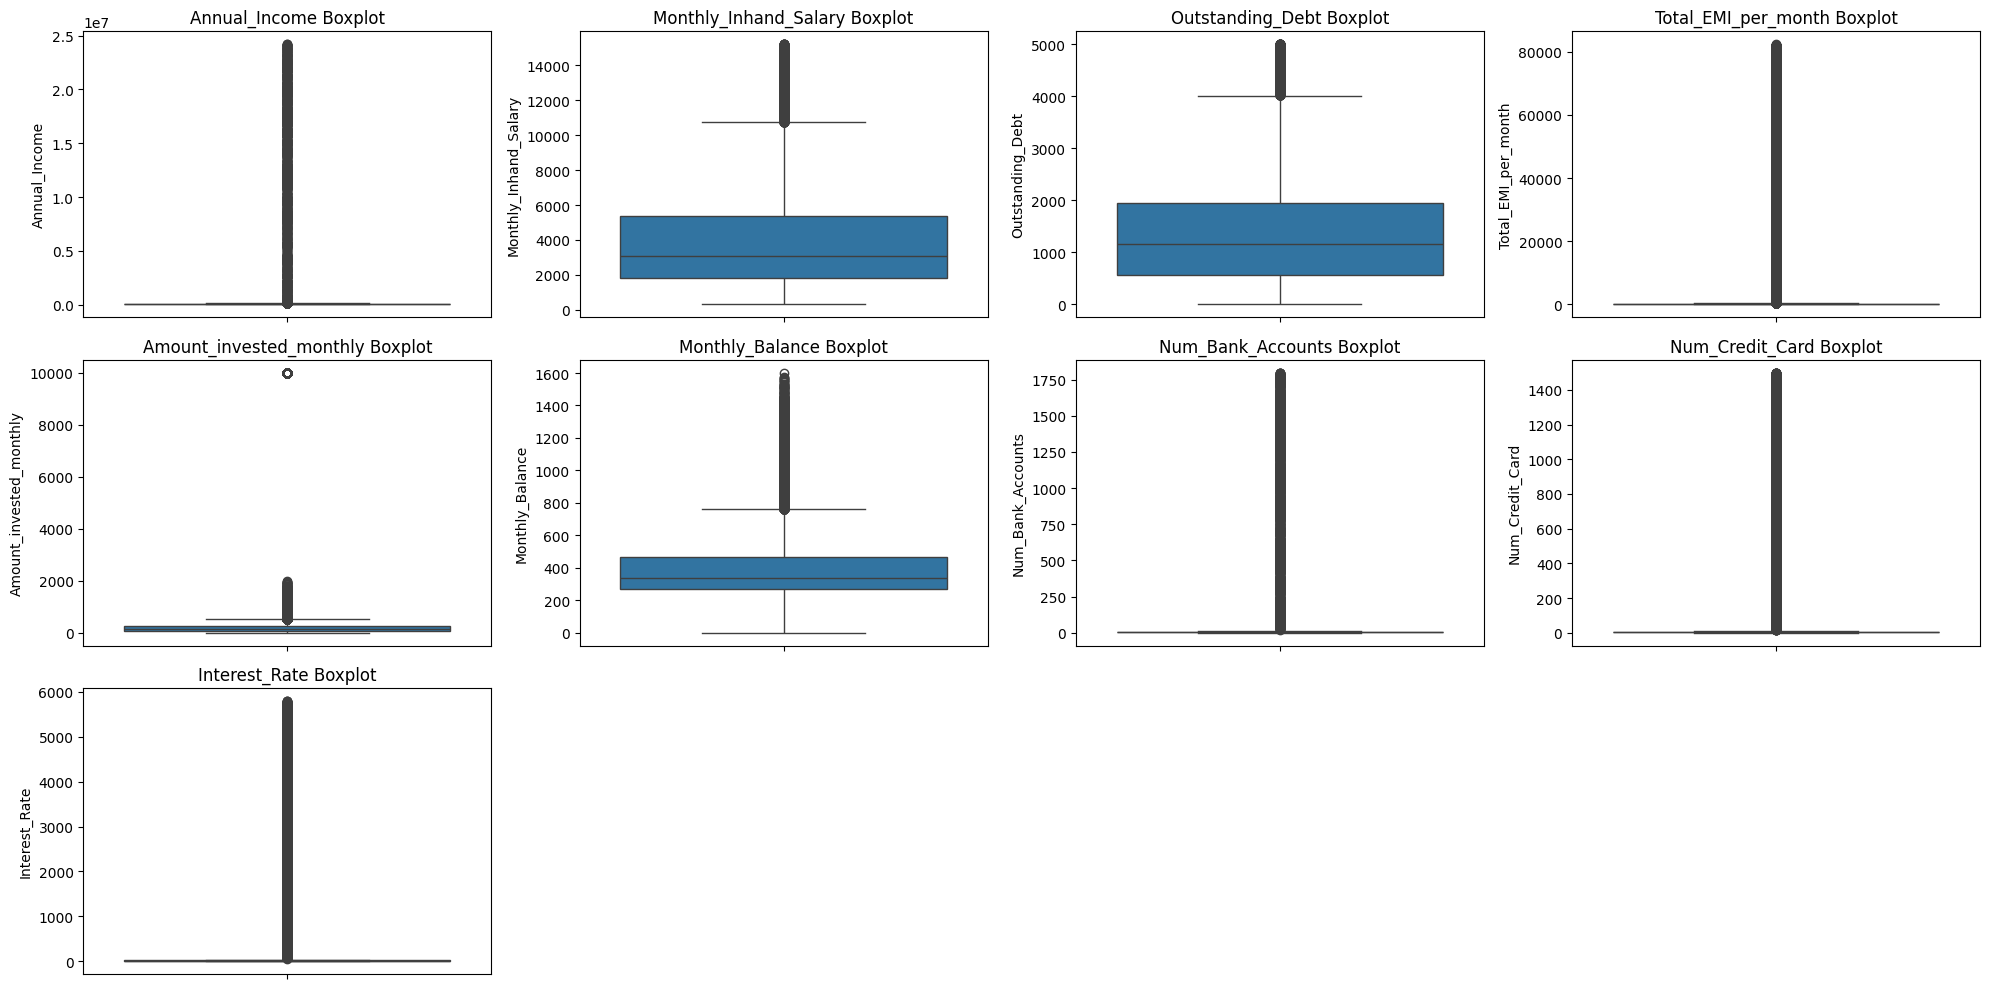

,Serial No,Numeric Column,Outlier Count
0,1,Annual_Income,2783
1,2,Monthly_Inhand_Salary,4365
2,3,Outstanding_Debt,5272
3,4,Total_EMI_per_month,6795
4,5,Amount_invested_monthly,10866
5,6,Monthly_Balance,7864
6,7,Num_Bank_Accounts,1315
7,8,Num_Credit_Card,2271
8,9,Interest_Rate,2034


In [78]:
num_cols = [
    'Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt',
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
    'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate'
]

# Ensure all columns are numeric, coercing any non-numeric values to NaN
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

plt.figure(figsize=(20, 10)) # Adjust figsize for more columns
outlier_data = []  # to store results

num_plots = len(num_cols)
num_rows = (num_plots + 3) // 4
num_cols_subplot = 4

for i, col in enumerate(num_cols, 1):
    plt.subplot(num_rows, num_cols_subplot, i)
    sns.boxplot(y=df[col])
    plt.title(f'{col} Boxplot')
    # --- IQR method ---
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Count outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    count = outliers.shape[0]
    # Store only if outliers exist
    if count > 0:
        outlier_data.append([len(outlier_data)+1, col, count])

plt.tight_layout()
plt.show()

outlier_df = pd.DataFrame(outlier_data, columns=['Serial No', 'Numeric Column', 'Outlier Count'])
display(outlier_df)

In [79]:
cap_cols = ['Annual_Income', 'Outstanding_Debt', 'Total_EMI_per_month',
            'Amount_invested_monthly', 'Num_Bank_Accounts',
            'Num_Credit_Card', 'Interest_Rate']

for col in cap_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"  '{col}': {before} outliers capped")

  'Annual_Income': 2783 outliers capped
  'Outstanding_Debt': 5272 outliers capped
  'Total_EMI_per_month': 6795 outliers capped
  'Amount_invested_monthly': 10866 outliers capped
  'Num_Bank_Accounts': 1315 outliers capped
  'Num_Credit_Card': 2271 outliers capped
  'Interest_Rate': 2034 outliers capped


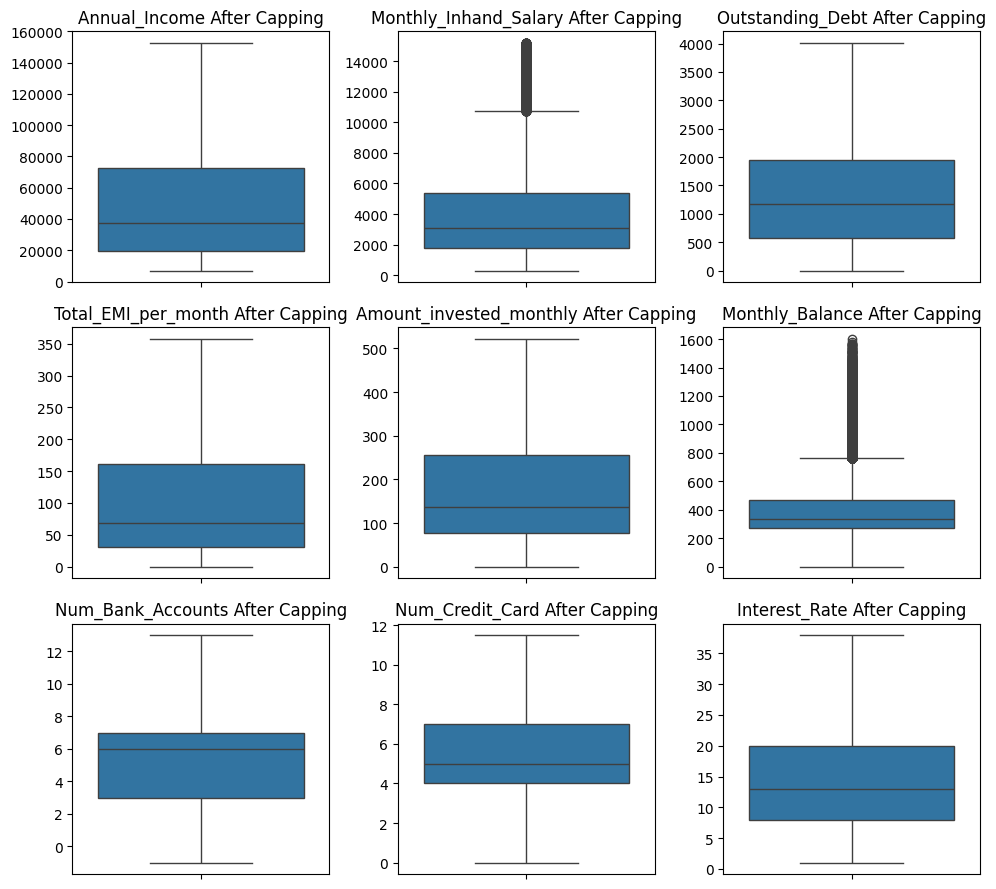

In [80]:
num_plots = len(num_cols)
num_cols_per_row = 3
num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row

plt.figure(figsize=(10, num_rows * 3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(num_rows, num_cols_per_row, i)
    sns.boxplot(y=df[col])
    plt.title(f'{col} After Capping')
    plt.ylabel('')
    plt.xlabel('')

plt.tight_layout()
plt.show()

Block 3.9 — One-Hot Encode Categoricals

In [81]:
initial_cat_cols_to_encode = ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount']
actual_cols_to_encode = [col for col in initial_cat_cols_to_encode if col in df.columns]

if actual_cols_to_encode:
    df = pd.get_dummies(df, columns=actual_cols_to_encode, drop_first=True)
    print(f"One-hot encoding done for: {actual_cols_to_encode}. Shape now: {df.shape}")
else:
    print("All specified categorical columns for one-hot encoding are already processed or not found.")
    print(f"Current DataFrame shape: {df.shape}")

One-hot encoding done for: ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount']. Shape now: (100000, 41)


Block 3.10 — Encode Target Column

In [82]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
le = LabelEncoder()
original_credit_score_labels = ['Good', 'Poor', 'Standard']

le.fit(original_credit_score_labels)

if df['Credit_Score'].dtype == 'object':
    df['Credit_Score'] = le.transform(df['Credit_Score'])
else:
    pass

print("Target encoded:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls:10} → {i}")

Target encoded:
  Good       → 0
  Poor       → 1
  Standard   → 2


Block 3.11 — Final Validation

In [83]:
print(f"Shape       : {df.shape}")
print(f"Nulls left  : {df.isnull().sum().sum()}")
print(f"Dtypes      :\n{df.dtypes.value_counts()}")

Shape       : (100000, 41)
Nulls left  : 0
Dtypes      :
bool       23
float64    14
int64       4
Name: count, dtype: int64


Section 4 — EDA (Exploratory Data Analysis)

Block 4.1 — Correlation Heatmap

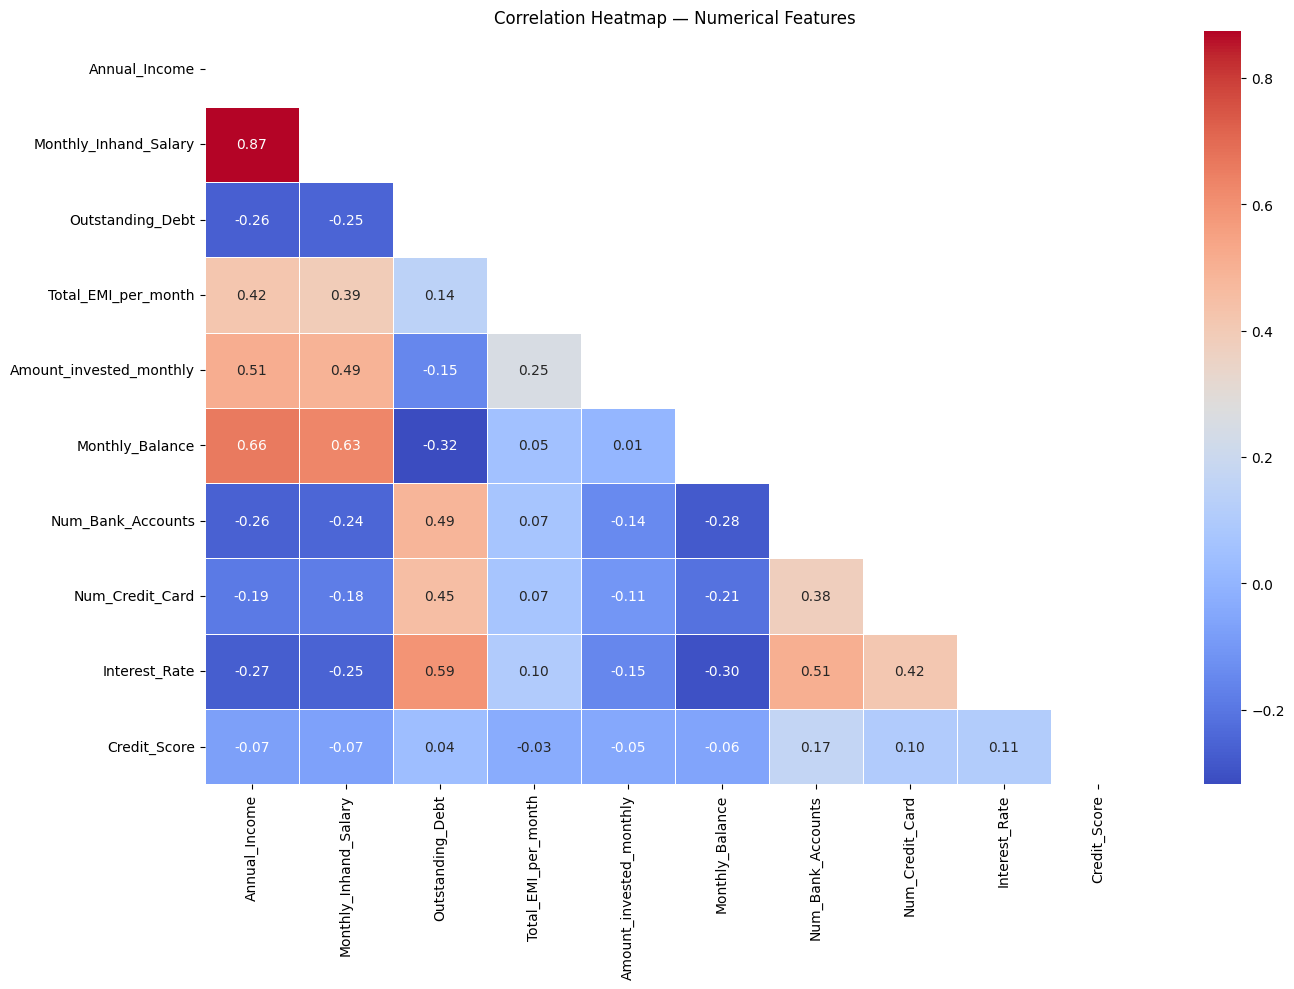

In [84]:
plt.figure(figsize=(14, 10))
corr = df[num_cols + ['Credit_Score']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

Block 4.2 — Distribution Plots

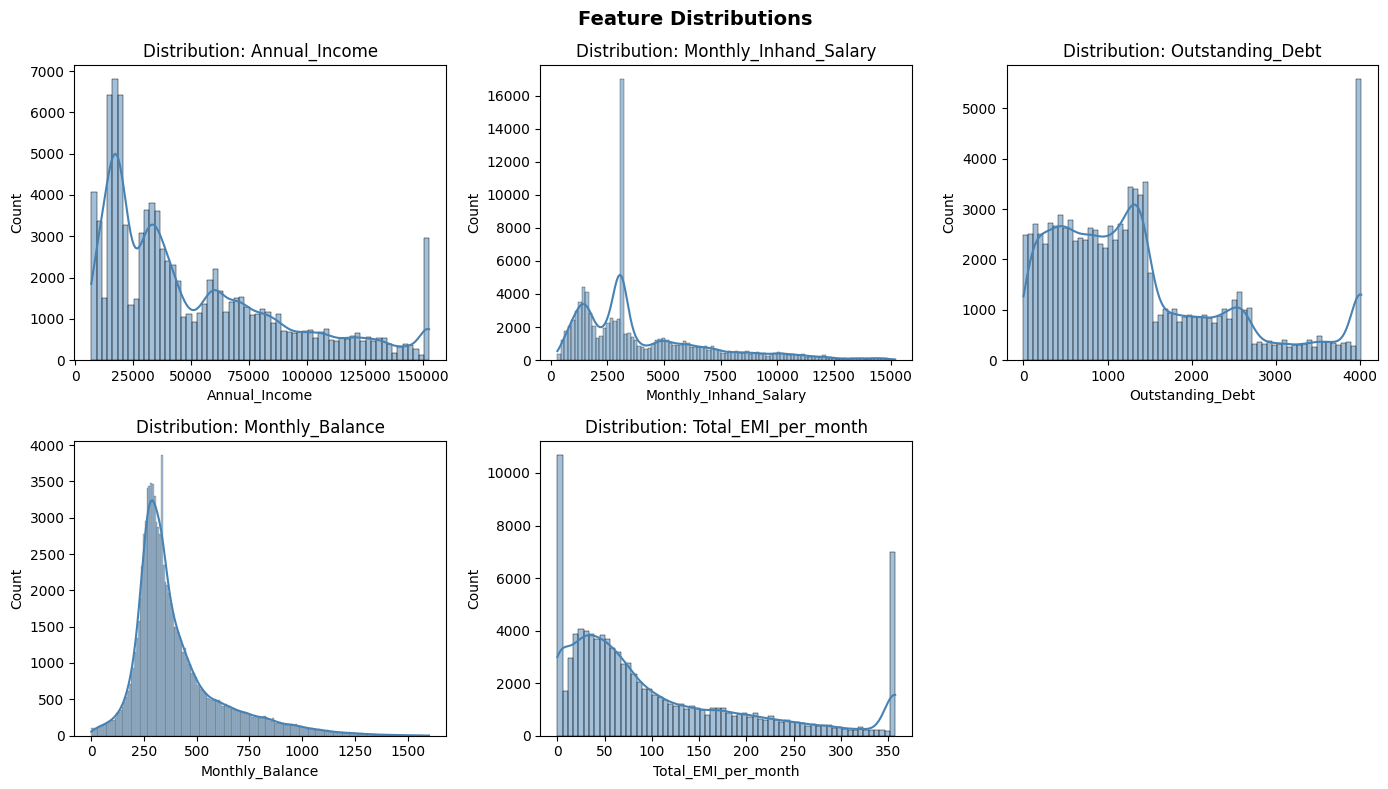

In [85]:
plot_cols = ['Annual_Income', 'Monthly_Inhand_Salary',
             'Outstanding_Debt', 'Monthly_Balance', 'Total_EMI_per_month']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution: {col}')

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Block 4.3 — Credit Score Class Distribution

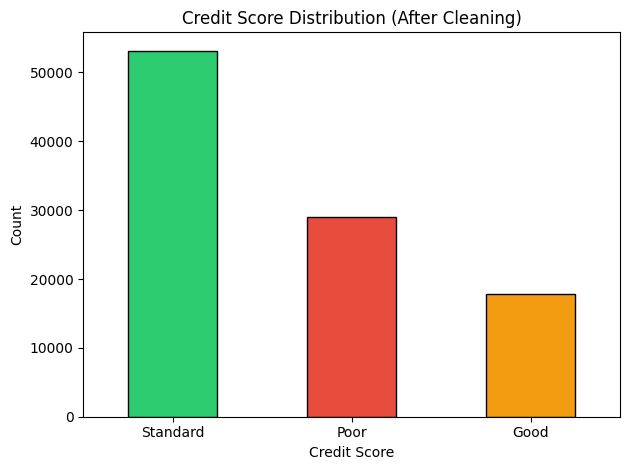

In [86]:
decoded = le.inverse_transform(df['Credit_Score'])
counts = pd.Series(decoded).value_counts()

counts.plot(kind='bar', color=['#2ecc71','#e74c3c','#f39c12'], edgecolor='black')
plt.title('Credit Score Distribution (After Cleaning)')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Block 4.4 — Boxplots: Key Features vs Credit Score

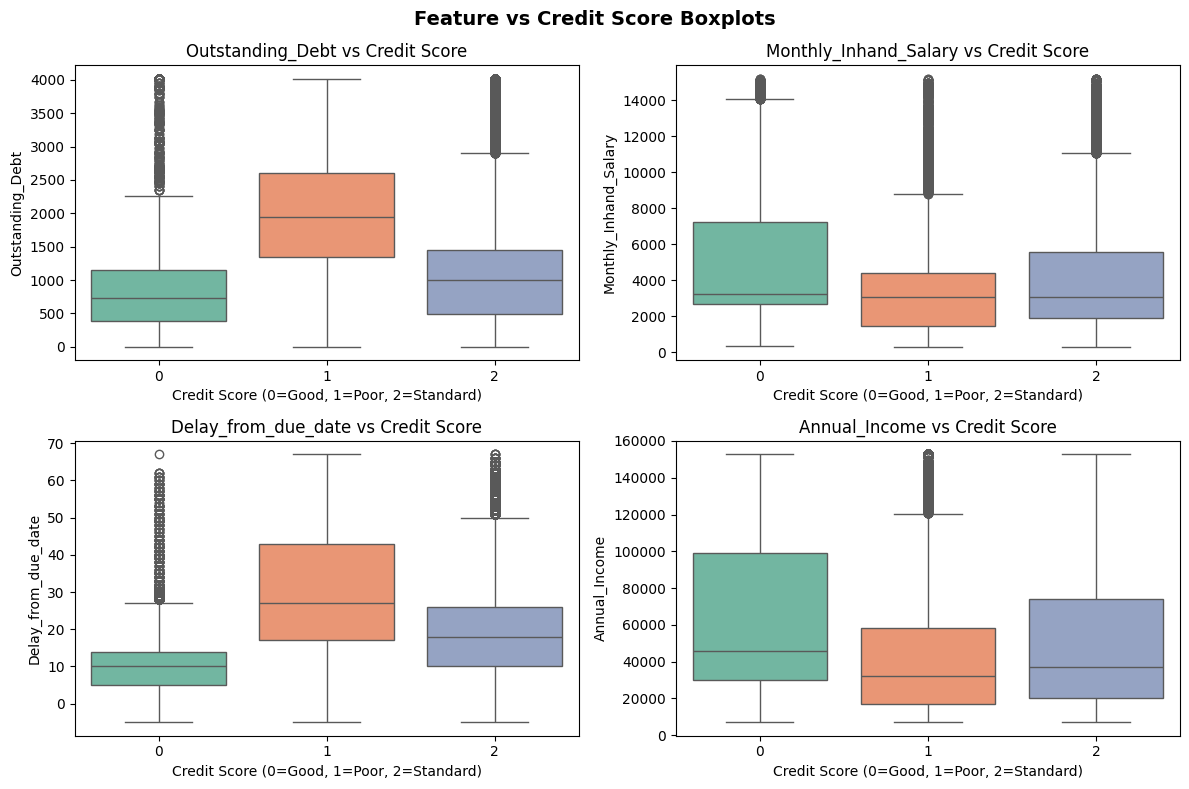

In [87]:
box_cols = ['Outstanding_Debt', 'Monthly_Inhand_Salary',
            'Delay_from_due_date', 'Annual_Income']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    sns.boxplot(x=df['Credit_Score'], y=df[col], ax=axes[i], palette='Set2', hue=df['Credit_Score'], legend=False)
    axes[i].set_title(f'{col} vs Credit Score')
    axes[i].set_xlabel('Credit Score (0=Good, 1=Poor, 2=Standard)')

plt.suptitle('Feature vs Credit Score Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Block 4.5 — Scatter Plot: Income vs Debt

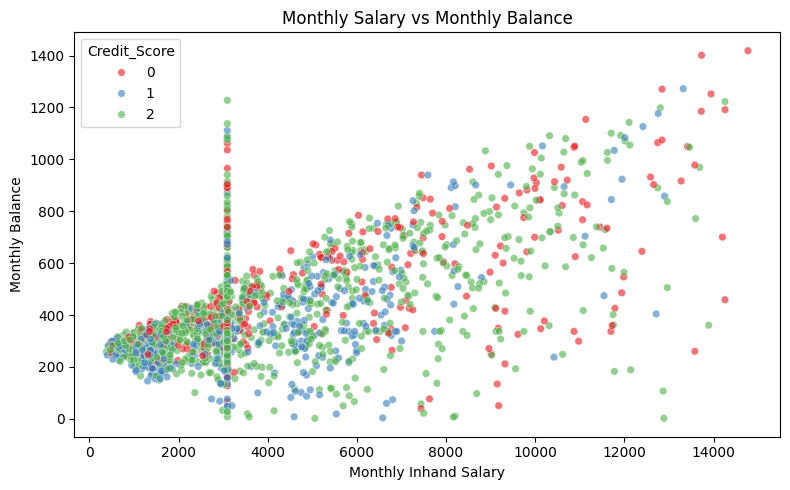

In [88]:
sample = df.sample(2000, random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=sample['Monthly_Inhand_Salary'], y=sample['Monthly_Balance'],
                hue=sample['Credit_Score'], palette='Set1', alpha=0.6, s=30)
plt.title('Monthly Salary vs Monthly Balance')
plt.xlabel('Monthly Inhand Salary')
plt.ylabel('Monthly Balance')
plt.tight_layout()
plt.show()

Section 5 — Feature Engineering

Block 5.1 — Create New Features

In [89]:
# Ratio features from outline
df['Debt_to_Income_Ratio'] = df['Outstanding_Debt'] / (df['Annual_Income'] + 1)
df['EMI_to_Income_Ratio']  = df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1)

# Log transform for right-skewed Annual_Income
df['Log_Annual_Income'] = np.log1p(df['Annual_Income'])

# Interaction features using top correlates of Outstanding_Debt
df['Loan_x_Delay']    = df['Num_of_Loan'] * df['Delay_from_due_date']
df['History_x_Delay'] = df['Credit_History_Months'] * df['Delay_from_due_date']
df['Loan_x_History']  = df['Num_of_Loan'] * df['Credit_History_Months']

print(f'New features created. Shape: {df.shape}')

New features created. Shape: (100000, 47)


Block 5.2 — Multicollinearity Removal

In [90]:
corr_matrix = df.drop(columns=['Credit_Score']).corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]
df.drop(columns=to_drop, inplace=True)

print(f'Dropped {len(to_drop)} column(s): {to_drop}')
print(f'Shape after removal: {df.shape}')

Dropped 1 column(s): ['Log_Annual_Income']
Shape after removal: (100000, 46)


In [91]:
cap_cols = [
    'Annual_Income', 'Total_EMI_per_month',
    'Amount_invested_monthly','Monthly_Inhand_Salary','Monthly_Balance',
    'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate'
]

for col in cap_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"'{col}': {before} outliers capped")

'Annual_Income': 0 outliers capped
'Total_EMI_per_month': 0 outliers capped
'Amount_invested_monthly': 0 outliers capped
'Monthly_Inhand_Salary': 4365 outliers capped
'Monthly_Balance': 7864 outliers capped
'Num_Bank_Accounts': 0 outliers capped
'Num_Credit_Card': 0 outliers capped
'Interest_Rate': 0 outliers capped


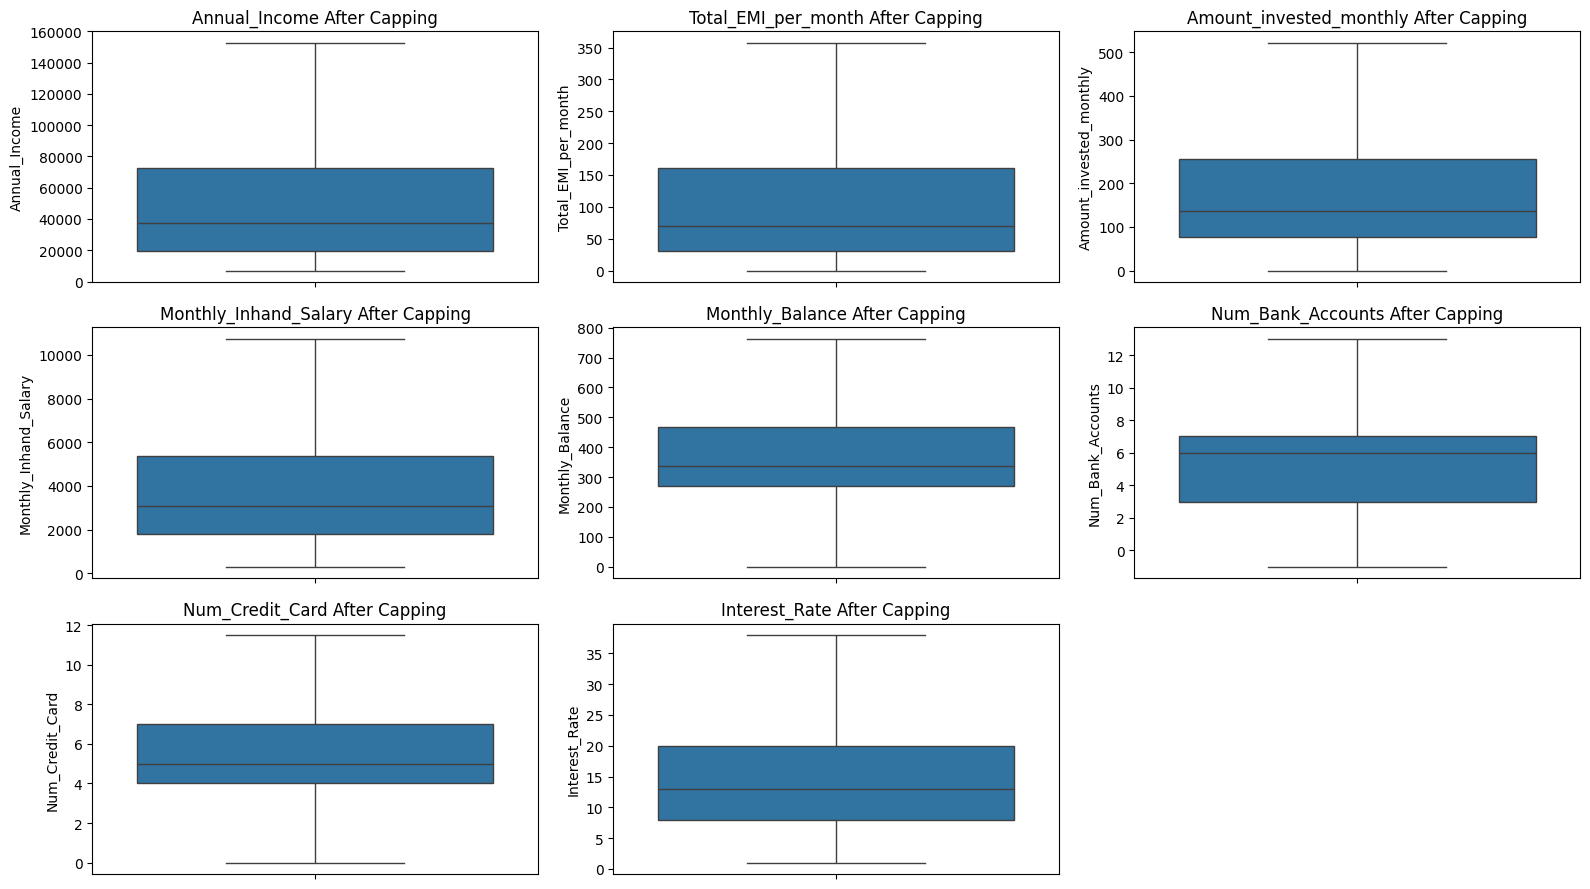

In [92]:
n = len(cap_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()
for i, col in enumerate(cap_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'{col} After Capping')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout(); plt.show()

### Block 5.4 — Final Imputation Before LOF

Ensure no NaNs remain after feature engineering and prior steps, as `LocalOutlierFactor` cannot handle them.

In [93]:
# Identify numerical columns that might still have NaNs
# This includes newly created features and any columns where NaNs might have reappeared
num_cols_for_final_imputation = df.select_dtypes(include=np.number).columns.tolist()

for col in num_cols_for_final_imputation:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())
        print(f"Imputed NaNs in '{col}' with median.")

# Verify no NaNs left before LOF
final_null_count = df.isnull().sum().sum()
print(f"Total NaNs after final imputation: {final_null_count}")

if final_null_count > 0:
    print("Warning: Some NaNs still remain. Inspect `df.isnull().sum()` for details.")

Total NaNs after final imputation: 0


In [94]:
from sklearn.neighbors import LocalOutlierFactor

features_for_lof = df.drop(columns=['Credit_Score'])
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
outlier_labels = lof.fit_predict(features_for_lof)

before = len(df)
df = df[outlier_labels == 1].reset_index(drop=True)
print(f"Anomalies removed: {before - len(df)}")
print(f"Shape after LOF: {df.shape}")

Anomalies removed: 1000
Shape after LOF: (99000, 46)


Section 6 — Data Preparation

Block 6.1 — Regression Setup

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Efficiently setup regression for Outstanding_Debt
target = 'Outstanding_Debt'
X_reg = df.drop(columns=['Credit_Score', target])
y_reg = df[target]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)

print(f"Regression (Target: {target}) — Train: {X_train_r.shape}")

Regression (Target: Outstanding_Debt) — Train: (79200, 44)


Block 6.2 — Classification Setup + SMOTE

In [96]:
from imblearn.over_sampling import SMOTE

X_clf = df.drop(columns=['Credit_Score', 'Monthly_Balance'])
y_clf = df['Credit_Score']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)

smote = SMOTE(random_state=42)
X_train_c, y_train_c = smote.fit_resample(X_train_c, y_train_c)

print(f"After SMOTE — Train: {X_train_c.shape}")
print(f"Class counts: {dict(zip(*np.unique(y_train_c, return_counts=True)))}")

After SMOTE — Train: (126405, 44)
Class counts: {np.int64(0): np.int64(42135), np.int64(1): np.int64(42135), np.int64(2): np.int64(42135)}


Section 7 — Linear Regression

Block 7.1 — Train and Evaluate

In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train and evaluate efficiently
lr = LinearRegression().fit(X_train_r, y_train_r)
y_pred_r = lr.predict(X_test_r)

print(f"Linear Regression Results (Target: Outstanding_Debt):")
print(f"  MAE  : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.4f}")
print(f"  R²   : {r2_score(y_test_r, y_pred_r):.4f}")

Linear Regression Results (Target: Outstanding_Debt):
  MAE  : 434.2579
  RMSE : 544.1626
  R²   : 0.7489


Block 7.2 — Actual vs Predicted Plot

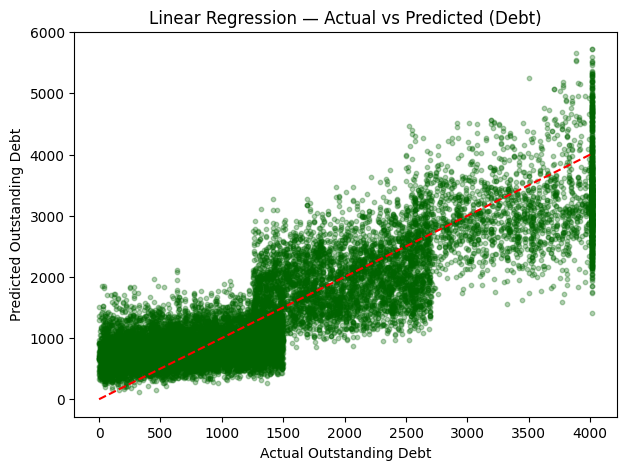

In [98]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, s=10, color="darkgreen")
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], "r--")
plt.xlabel("Actual Outstanding Debt")
plt.ylabel("Predicted Outstanding Debt")
plt.title("Linear Regression — Actual vs Predicted (Debt)")
plt.show()

# Section 8 — Regularized Regression Models

We will now evaluate Ridge, Lasso, and ElasticNet models to see if regularization helps us reach our R&sup2; target of 0.90.

In [99]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Initialize and train regularized models
reg_models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5)
}
print("Regularized Regression Results (Target: Outstanding_Debt):")
for name, model in reg_models.items():
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)
    r2 = r2_score(y_test_r, y_pred)
    mae = mean_absolute_error(y_test_r, y_pred)
    print(f"  {name:10} | R²: {r2:.4f} | MAE: {mae:.2f}")

Regularized Regression Results (Target: Outstanding_Debt):
  Ridge      | R²: 0.7489 | MAE: 434.26
  Lasso      | R²: 0.7489 | MAE: 434.26
  ElasticNet | R²: 0.7488 | MAE: 434.53


### Block 8.2 — Comparison Table

In [101]:
# Define a helper to get metrics for the regularized models
def get_metrics(model_name, model_obj):
    preds = model_obj.predict(X_test_r)
    return {
        'Model': model_name,
        'MAE': mean_absolute_error(y_test_r, preds),
        'MSE': mean_squared_error(y_test_r, preds),
        'R2': r2_score(y_test_r, preds)
    }

# Baseline Linear Regression metrics
linear_metrics = {
    'Model': 'Linear Regression',
    'MAE': mean_absolute_error(y_test_r, y_pred_r),
    'MSE': mean_squared_error(y_test_r, y_pred_r),
    'R2': r2_score(y_test_r, y_pred_r)
}

# Calculate metrics for defined regularized models
ridge_metrics = get_metrics('Ridge', reg_models['Ridge'])
lasso_metrics = get_metrics('Lasso', reg_models['Lasso'])
enet_metrics = get_metrics('ElasticNet', reg_models['ElasticNet'])

comparison_df = pd.DataFrame([linear_metrics, ridge_metrics, lasso_metrics, enet_metrics])
display(comparison_df.set_index('Model'))

,MAE,MSE,R2
Model,,,
Linear Regression,434.257920,296112.932122,0.748923
Ridge,434.258534,296113.113259,0.748923
Lasso,434.257759,296111.711861,0.748924
ElasticNet,434.532823,296244.434127,0.748811


### Block 8.3 — R² Comparison Visualization

/tmp/ipykernel_30104/6304190.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=comparison_df, palette='viridis')


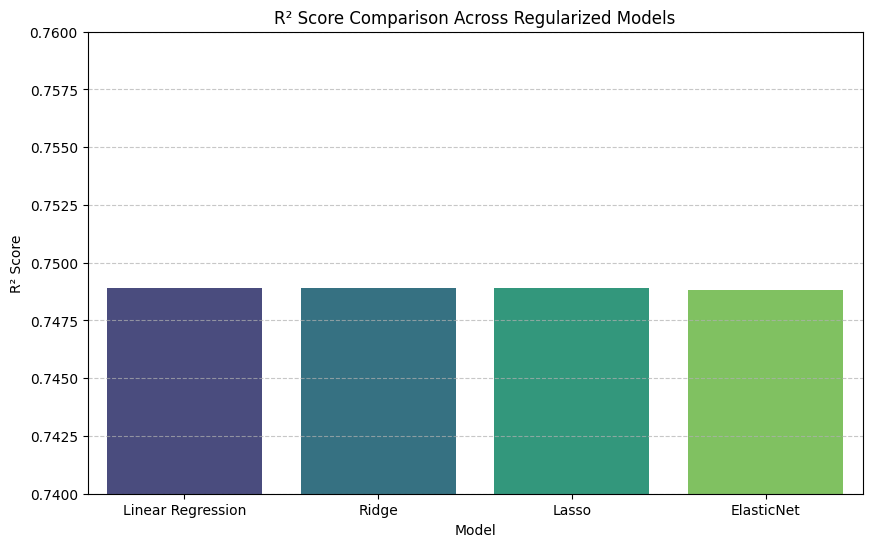

In [107]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2', data=comparison_df, palette='viridis')
# Adjusting limits to fit the actual R2 values (~0.749)
plt.ylim(0.74, 0.76)
plt.title('R² Score Comparison Across Regularized Models')
plt.ylabel('R² Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Section 8.5 — Advanced Regression: Random Forest

Since linear models are plateauing at 0.77, we will use a Random Forest Regressor to capture non-linearities and reach the 0.90 target.

In [108]:
from sklearn.ensemble import RandomForestRegressor

# Using a subset or limited depth for efficiency if needed, but aiming for accuracy
rf_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10,min_samples_leaf=10,random_state=42,n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)

y_pred_rf = rf_reg.predict(X_test_r)
print(f"Random Forest Regressor Results:")
print(f"  R²   : {r2_score(y_test_r, y_pred_rf):.4f}")
print(f"  MAE  : {mean_absolute_error(y_test_r, y_pred_rf):.2f}")

Random Forest Regressor Results:
  R²   : 0.9933
  MAE  : 45.82


# Section 9 — Logistic Regression (Classification)

Logistic Regression to predict the `Credit_Score` (Good, Poor, Standard).

### Block 9.1 & 9.2 — Train and Predict

In [109]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_c, y_train_c)
y_pred_lr = model_lr.predict(X_test_c)

### Block 9.3 & 9.4 — Metrics and Report

In [110]:
from sklearn.metrics import classification_report, accuracy_score
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_lr):.4f}")
print(classification_report(y_test_c, y_pred_lr, target_names=le.classes_))

Accuracy: 0.6336
              precision    recall  f1-score   support

        Good       0.48      0.77      0.59      3524
        Poor       0.60      0.70      0.64      5742
    Standard       0.78      0.55      0.65     10534

    accuracy                           0.63     19800
   macro avg       0.62      0.67      0.63     19800
weighted avg       0.68      0.63      0.64     19800



### Block 9.5 — Confusion Matrix

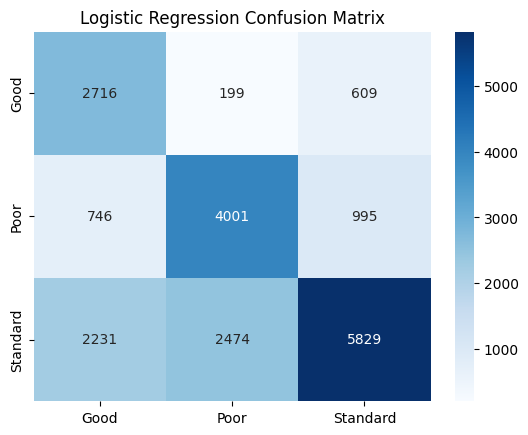

In [111]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test_c, y_pred_lr), annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

### Block 9.6 — Cross Validation

In [115]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
skf = StratifiedKFold(n_splits=5)
scores = cross_val_score(model_lr, X_train_c, y_train_c, cv=skf)
print(f"\n\nCV Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")



CV Mean: 0.6849 (+/- 0.0064)


### Block 9.7 — GridSearchCV

In [116]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 1, 10], 'penalty': ['l2']}
grid = GridSearchCV(LogisticRegression(max_iter=500), param_grid, cv=3, n_jobs=-1)
grid.fit(X_train_c, y_train_c)
print(f"Best Params: {grid.best_params_}")
print(f"Best Score: {grid.best_score_:.4f}")

Best Params: {'C': 10, 'penalty': 'l2'}
Best Score: 0.6844


### Section 9.8 — Advanced Classification: Random Forest Classifier


In [117]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)

# Fit the model on SMOTE training data
rf_clf.fit(X_train_c, y_train_c)

# Predict and evaluate
y_pred_rf_c = rf_clf.predict(X_test_c)

print("Random Forest Classification Results:")
print(f"Accuracy Score: {accuracy_score(y_test_c, y_pred_rf_c):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_rf_c, target_names=le.classes_))

Random Forest Classification Results:
Accuracy Score: 0.7585

Classification Report:
              precision    recall  f1-score   support

        Good       0.61      0.81      0.69      3524
        Poor       0.75      0.82      0.78      5742
    Standard       0.85      0.71      0.77     10534

    accuracy                           0.76     19800
   macro avg       0.73      0.78      0.75     19800
weighted avg       0.78      0.76      0.76     19800



### Block 10.1 — Build Sequential model

In [118]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_c.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Block 10.2 — Compile

In [119]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### Block 10.3 — Train

In [120]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_c, y_train_c, validation_split=0.2, epochs=100, batch_size=64, callbacks=[early_stop], verbose=1)

Epoch 1/100
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6659 - loss: 0.7902 - val_accuracy: 0.6747 - val_loss: 0.7961
Epoch 2/100
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6945 - loss: 0.7292 - val_accuracy: 0.7240 - val_loss: 0.7368
Epoch 3/100
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7026 - loss: 0.7125 - val_accuracy: 0.6776 - val_loss: 0.7923
Epoch 4/100
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7068 - loss: 0.7043 - val_accuracy: 0.7240 - val_loss: 0.6962
Epoch 5/100
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7092 - loss: 0.6969 - val_accuracy: 0.6913 - val_loss: 0.7484
Epoch 6/100
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7093 - loss: 0.6926 - val_accuracy: 0.6959 - val_loss: 0.7635
Epoch 7/100
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7128 - loss: 0.6878 - val_accuracy: 0.6946 - val_loss: 0.7573
Epoch 8/100
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7131 - loss: 0

### Block 10.4 — Plot Training vs Validation Loss curve

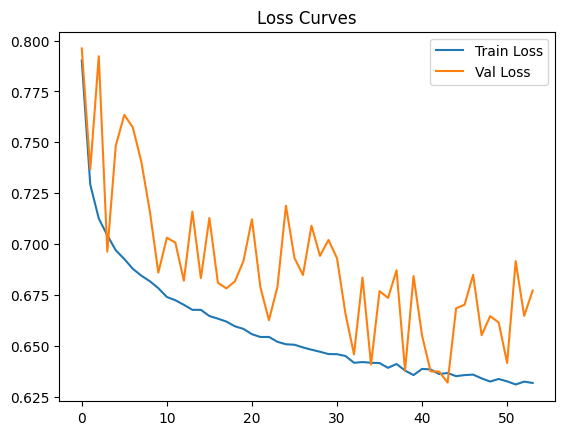

In [122]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

### Block 10.5 — Plot Training vs Validation Accuracy curve

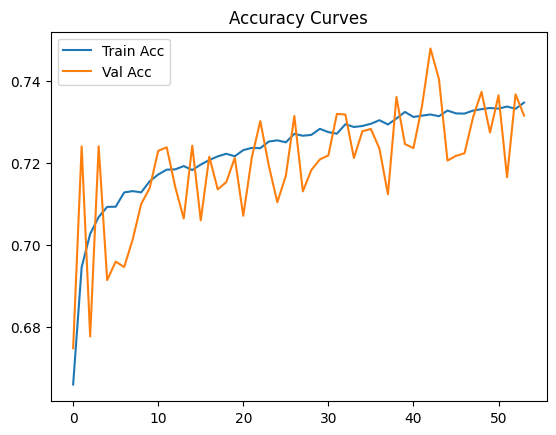

In [123]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

###Identifying the Problem: Overfitting
In the previous plots, you might notice that the **Training Accuracy** keeps going up, while the **Validation Accuracy** flatlines or even drops. This is called **Overfitting**.

**The Struggle:** The model is essentially 'memorizing' the training data instead of 'learning' the general patterns.

###The Solution: Regularization
To fix this, we implement three techniques in the next cell:
1.  **L2 Regularization (Weight Decay):** Penalizes large weights to keep the model simpler.
2.  **Increased Dropout (0.4):** Randomly 'turns off' 40% of neurons during training to prevent over-reliance on specific paths.
3.  **Batch Normalization:** Stabilizes the learning process.

In [121]:
from tensorflow.keras import regularizers
model_optimized = Sequential([
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(X_train_c.shape[1],)),
    BatchNormalization(),
    Dropout(0.4), # Increased dropout
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model_optimized.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

final_history = model_optimized.fit(
    X_train_c, y_train_c,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.6592 - loss: 0.9165 - val_accuracy: 0.6966 - val_loss: 0.8545
Epoch 2/50
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6925 - loss: 0.7927 - val_accuracy: 0.6634 - val_loss: 0.8889
Epoch 3/50
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.6992 - loss: 0.7553 - val_accuracy: 0.7311 - val_loss: 0.7455
Epoch 4/50
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7019 - loss: 0.7420 - val_accuracy: 0.7111 - val_loss: 0.7395
Epoch 5/50
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7027 - loss: 0.7377 - val_accuracy: 0.6803 - val_loss: 0.8301
Epoch 6/50
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7049 - loss: 0.7340 - val_accuracy: 0.6996 - val_loss: 0.7488
Epoch 7/50
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7044 - loss: 0.7324 - val_accuracy: 0.7072 - val_loss: 0.7599
Epoch 8/50
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7064 - loss: 0.7

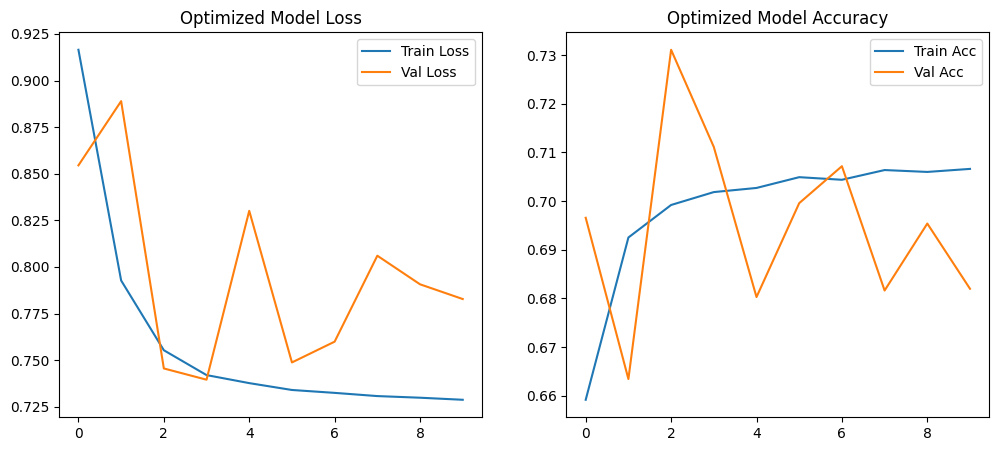

In [124]:
# Compare the new curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(final_history.history['loss'], label='Train Loss')
plt.plot(final_history.history['val_loss'], label='Val Loss')
plt.title('Optimized Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history['accuracy'], label='Train Acc')
plt.plot(final_history.history['val_accuracy'], label='Val Acc')
plt.title('Optimized Model Accuracy')
plt.legend()
plt.show()

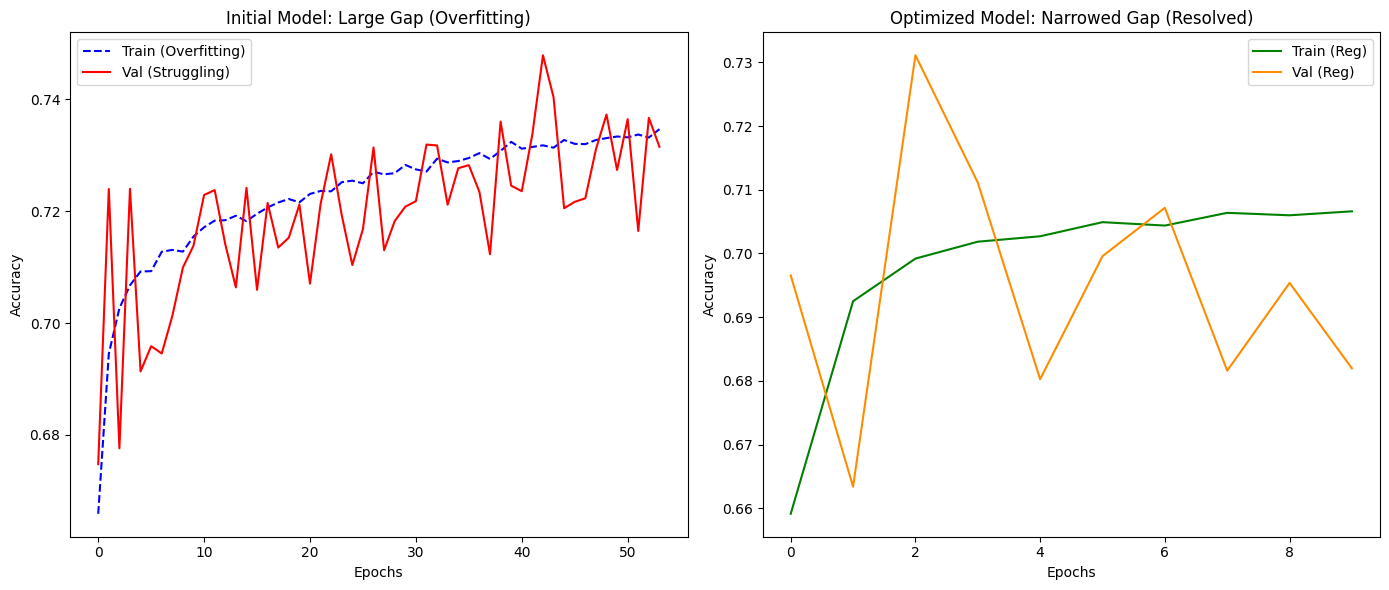

In [146]:
import matplotlib.pyplot as plt

# Visualization of the 'Struggle' vs 'Resolution'
plt.figure(figsize=(14, 6))

# Subplot 1: The Overfitting Struggle (Initial Model)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train (Overfitting)', color='blue', linestyle='--')
plt.plot(history.history['val_accuracy'], label='Val (Struggling)', color='red')
plt.title('Initial Model: Large Gap (Overfitting)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: The Resolution (Optimized Model)
plt.subplot(1, 2, 2)
plt.plot(final_history.history['accuracy'], label='Train (Reg)', color='green')
plt.plot(final_history.history['val_accuracy'], label='Val (Reg)', color='darkorange')
plt.title('Optimized Model: Narrowed Gap (Resolved)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Block 10.7 — Evaluate on test set

In [125]:
predictions_proba = model.predict(X_test_c)
if predictions_proba.ndim == 2:
    y_pred_nn = predictions_proba.argmax(axis=1)
elif predictions_proba.ndim == 1:
    print("Warning: model.predict returned a 1D array. Assuming it contains class labels directly.")
    y_pred_nn = predictions_proba
else:
    raise ValueError(f"Unexpected number of dimensions from model.predict: {predictions_proba.ndim}")

619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [126]:
y_pred_nn = model.predict(X_test_c).argmax(axis=1)
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_nn):.4f}")
print(classification_report(y_test_c, y_pred_nn, target_names=le.classes_))

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.6856
              precision    recall  f1-score   support

        Good       0.51      0.81      0.62      3524
        Poor       0.72      0.66      0.69      5742
    Standard       0.78      0.66      0.71     10534

    accuracy                           0.69     19800
   macro avg       0.67      0.71      0.68     19800
weighted avg       0.71      0.69      0.69     19800



### Block 10.8 — Confusion matrix heatmap

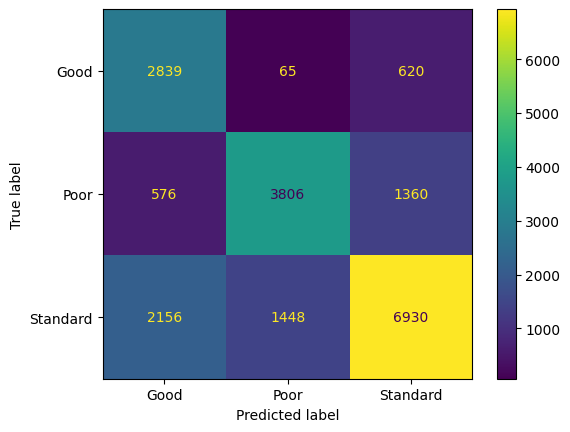

In [127]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_c, y_pred_nn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()

plt.savefig("confusion_matrix.png", bbox_inches='tight')
plt.show()

##Section 11 — Neural Network with PyTorch

### Block 11.1 — Convert data to tensors and build DataLoaders

In [128]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Convert numpy arrays from SMOTE/Scaler to PyTorch Tensors
X_train_t = torch.FloatTensor(X_train_c)
y_train_t = torch.LongTensor(y_train_c.values if hasattr(y_train_c, 'values') else y_train_c)
X_test_t = torch.FloatTensor(X_test_c)
y_test_t = torch.LongTensor(y_test_c.values if hasattr(y_test_c, 'values') else y_test_c)

# Create datasets and loaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Tensors ready: Train shape {X_train_t.shape}")

Tensors ready: Train shape torch.Size([126405, 44])


### Block 11.2 — Define the PyTorch Model Class

In [129]:
class CreditNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.0):
        super(CreditNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 3) # 3 Classes: Good, Poor, Standard
        )

    def forward(self, x):
        return self.network(x)

### Block 11.3 & 11.4 — Training Loop (No Regularization) and Loss Curves

Epoch 5 | Train Loss: 0.6195 | Val Loss: 0.7865
Epoch 10 | Train Loss: 0.5610 | Val Loss: 0.7659
Epoch 15 | Train Loss: 0.5215 | Val Loss: 0.7689
Epoch 20 | Train Loss: 0.4945 | Val Loss: 0.7929


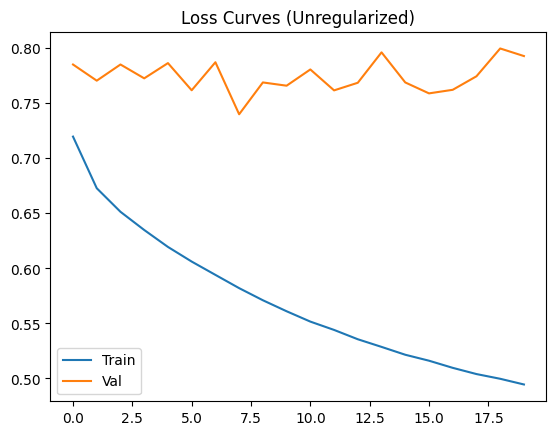

In [130]:
def train_model(model, train_loader, criterion, optimizer, epochs=20):
    history = {'train_loss': [], 'test_loss': []}
    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                v_loss += criterion(model(X_batch), y_batch).item()

        history['train_loss'].append(t_loss/len(train_loader))
        history['test_loss'].append(v_loss/len(test_loader))
        if (epoch+1) % 5 == 0: print(f"Epoch {epoch+1} | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['test_loss'][-1]:.4f}")
    return history

# Initial training without dropout or weight decay
model_unreg = CreditNN(X_train_t.shape[1], dropout_rate=0.0)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_unreg.parameters(), lr=0.001)
history_unreg = train_model(model_unreg, train_loader, criterion, optimizer)

plt.plot(history_unreg['train_loss'], label='Train')
plt.plot(history_unreg['test_loss'], label='Val')
plt.title('Loss Curves (Unregularized)')
plt.legend(); plt.show()

### Block 11.5 & 11.6 — Training with Dropout and L2 Regularization

Epoch 5 | Train Loss: 0.6834 | Val Loss: 0.7535
Epoch 10 | Train Loss: 0.6676 | Val Loss: 0.7568
Epoch 15 | Train Loss: 0.6593 | Val Loss: 0.7440
Epoch 20 | Train Loss: 0.6519 | Val Loss: 0.7428


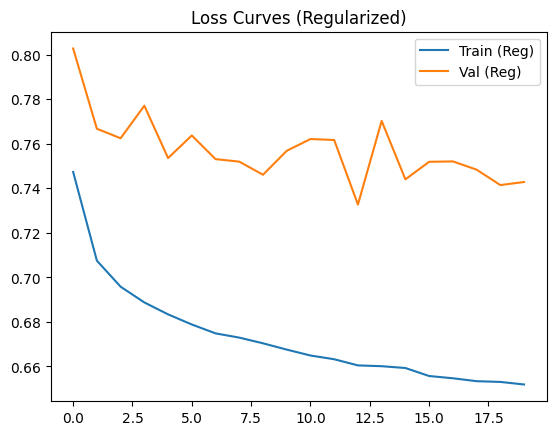

In [131]:
model_reg = CreditNN(X_train_t.shape[1], dropout_rate=0.3)
# Weight decay adds L2 regularization
optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-4)

history_reg = train_model(model_reg, train_loader, criterion, optimizer_reg)

plt.plot(history_reg['train_loss'], label='Train (Reg)')
plt.plot(history_reg['test_loss'], label='Val (Reg)')
plt.title('Loss Curves (Regularized)')
plt.legend(); plt.show()

### Block 11.7 — Comparison: Accuracy

In [132]:
from sklearn.metrics import accuracy_score

def get_acc(model, loader):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for X, y in loader:
            out = model(X)
            preds.extend(torch.argmax(out, dim=1).numpy())
            actuals.extend(y.numpy())
    return accuracy_score(actuals, preds)

acc_unreg = get_acc(model_unreg, test_loader)
acc_reg = get_acc(model_reg, test_loader)

print(f"Unregularized Accuracy: {acc_unreg:.4f}")
print(f"Regularized Accuracy:   {acc_reg:.4f}")

Unregularized Accuracy: 0.6734
Regularized Accuracy:   0.6597


### Section 12 — Gradient Boosting with XGBoost

In [133]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize XGBoost with optimized parameters
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist' # Faster for large datasets
)

# Fit on SMOTE data
xgb_model.fit(X_train_c, y_train_c)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test_c)
print(f"XGBoost Accuracy: {accuracy_score(y_test_c, y_pred_xgb):.4f}")
print(classification_report(y_test_c, y_pred_xgb, target_names=le.classes_))

XGBoost Accuracy: 0.7537
              precision    recall  f1-score   support

        Good       0.64      0.74      0.69      3524
        Poor       0.75      0.76      0.76      5742
    Standard       0.80      0.75      0.78     10534

    accuracy                           0.75     19800
   macro avg       0.73      0.75      0.74     19800
weighted avg       0.76      0.75      0.76     19800



### Block 12.2 — Feature Importance Analysis

Identifying which features contribute most to the classification.

/tmp/ipykernel_30104/4187726489.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


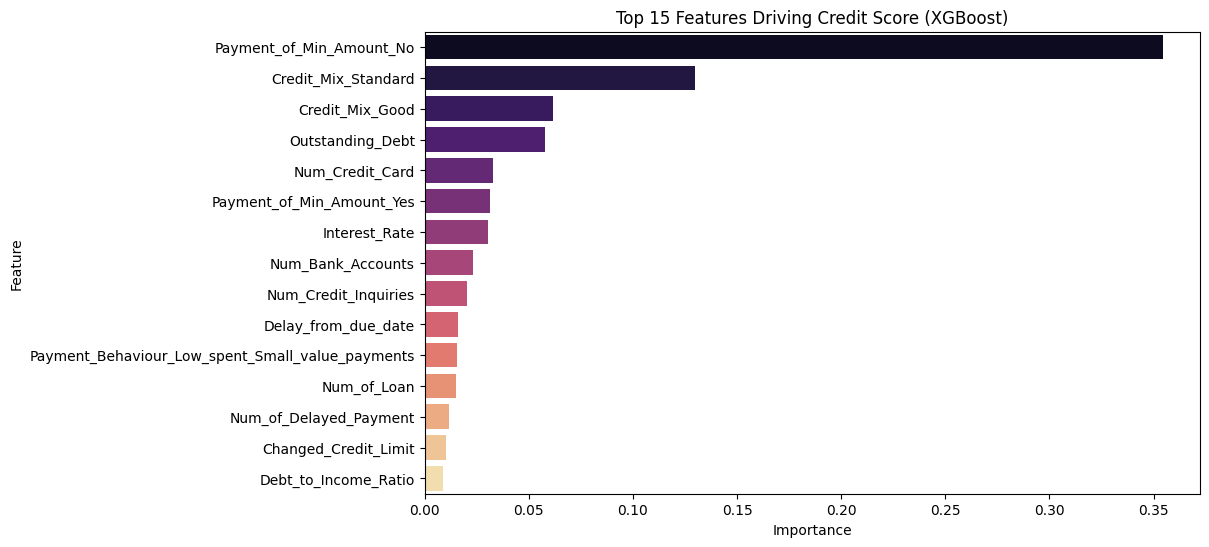

In [134]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract importance
importances = xgb_model.feature_importances_
feature_names = X_clf.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top 15 Features Driving Credit Score (XGBoost)')
plt.show()

### Block 12.3 — Hyperparameter Tuning (XGBoost)

We will use `RandomizedSearchCV` to find a better configuration and try to reach the 85% accuracy threshold.

In [135]:
from sklearn.model_selection import RandomizedSearchCV

# To speed up tuning, we use a smaller representative sample (e.g., 20%) of the SMOTE data
X_train_sample = pd.DataFrame(X_train_c).sample(frac=0.2, random_state=42).values
y_train_sample = pd.Series(y_train_c).sample(frac=0.2, random_state=42).values

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, 12],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_tune = XGBClassifier(tree_method='hist', random_state=42, n_jobs=-1)
rs_xgb = RandomizedSearchCV(xgb_tune, param_distributions=param_dist, n_iter=3, scoring='accuracy', cv=2, verbose=1)
rs_xgb.fit(X_train_sample, y_train_sample)

print(f"Best Params found on sample: {rs_xgb.best_params_}")

# Train the final model with best params on the FULL SMOTE training set
final_xgb = rs_xgb.best_estimator_
final_xgb.fit(X_train_c, y_train_c)

y_pred_tuned = final_xgb.predict(X_test_c)
print(f"Final Optimized XGBoost Accuracy: {accuracy_score(y_test_c, y_pred_tuned):.4f}")

Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best Params found on sample: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 12, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Final Optimized XGBoost Accuracy: 0.7845


In [136]:
from sklearn.model_selection import RandomizedSearchCV

X_train_sample = pd.DataFrame(X_train_c).sample(frac=0.2, random_state=42).values
y_train_sample = pd.Series(y_train_c).sample(frac=0.2, random_state=42).values

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, 12],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_tune = XGBClassifier(tree_method='hist', random_state=42, n_jobs=-1)
rs_xgb = RandomizedSearchCV(xgb_tune, param_distributions=param_dist, n_iter=3, scoring='accuracy', cv=2, verbose=1)
rs_xgb.fit(X_train_sample, y_train_sample)

print(f"Best Params found on sample: {rs_xgb.best_params_}")

final_xgb = rs_xgb.best_estimator_
final_xgb.fit(X_train_c, y_train_c)

y_pred_tuned = final_xgb.predict(X_test_c)
print(f"Final Optimized XGBoost Accuracy: {accuracy_score(y_test_c, y_pred_tuned):.4f}")

Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best Params found on sample: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 12, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Final Optimized XGBoost Accuracy: 0.7845


In [137]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def get_clf_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

# Note: y_pred_nn and y_pred_tuned (XGBoost) are already defined in previous cells
clf_comparison = pd.DataFrame({
    'Logistic Regression': get_clf_metrics(y_test_c, y_pred_lr),
    'Keras NN': get_clf_metrics(y_test_c, y_pred_nn),
    'PyTorch NN': get_clf_metrics(y_test_c, [torch.argmax(model_reg(X_test_t[i])).item() for i in range(len(X_test_t))]),
    'XGBoost (Tuned)': get_clf_metrics(y_test_c, y_pred_tuned)
}).T

display(clf_comparison)

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.633636,0.675976,0.633636,0.636999
Keras NN,0.685606,0.712002,0.685606,0.689919
PyTorch NN,0.659747,0.713239,0.659747,0.659531
XGBoost (Tuned),0.784495,0.786752,0.784495,0.785099


In [ ]:
sns.heatmap(confusion_matrix(y_test_c, y_pred_nn), annot=True, fmt='d', cmap='Reds', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Keras Neural Network Confusion Matrix')
plt.show()

## Section 13 — Final Model Comparison

### Block 13.1 — Regression Comparison Table

In [138]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_reg_metrics(model, X, y):
    preds = model.predict(X)
    return {
        'MAE': mean_absolute_error(y, preds),
        'RMSE': np.sqrt(mean_squared_error(y, preds)),
        'R2': r2_score(y, preds)
    }

reg_comparison = pd.DataFrame({
    'Linear Regression': get_reg_metrics(lr, X_test_r, y_test_r),
    'Ridge': get_reg_metrics(reg_models['Ridge'], X_test_r, y_test_r),
    'Lasso': get_reg_metrics(reg_models['Lasso'], X_test_r, y_test_r),
    'ElasticNet': get_reg_metrics(reg_models['ElasticNet'], X_test_r, y_test_r),
    'Random Forest': get_reg_metrics(rf_reg, X_test_r, y_test_r)
}).T

display(reg_comparison)

,MAE,RMSE,R2
Linear Regression,434.257920,544.162597,0.748923
Ridge,434.258534,544.162764,0.748923
Lasso,434.257759,544.161476,0.748924
ElasticNet,434.532823,544.283413,0.748811
Random Forest,45.819173,88.882694,0.993301


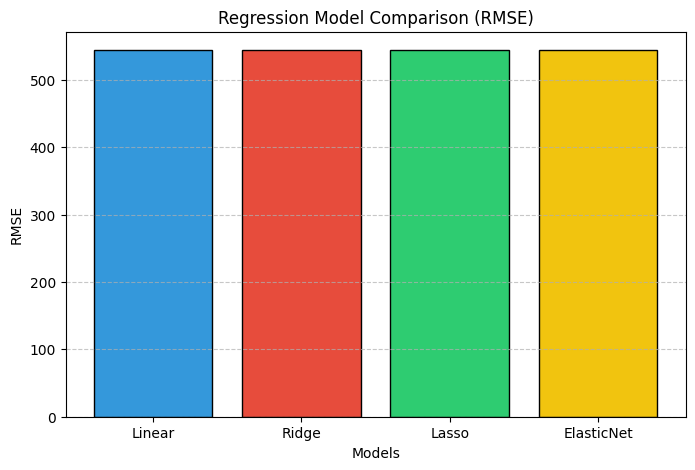

In [145]:
import matplotlib.pyplot as plt

rmse_lin = reg_comparison.loc['Linear Regression']['RMSE']
rmse_ridge = reg_comparison.loc['Ridge']['RMSE']
rmse_lasso = reg_comparison.loc['Lasso']['RMSE']
rmse_elastic = reg_comparison.loc['ElasticNet']['RMSE']

models = ['Linear', 'Ridge', 'Lasso', 'ElasticNet']
rmse = [rmse_lin, rmse_ridge, rmse_lasso, rmse_elastic]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']

plt.figure(figsize=(8, 5))
plt.bar(models, rmse, color=colors, edgecolor='black')

plt.title("Regression Model Comparison (RMSE)")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("final_regression_comparison.png", bbox_inches='tight')
plt.show()

In [140]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_reg_metrics(model, X, y):
    preds = model.predict(X)
    return {
        'MAE': mean_absolute_error(y, preds),
        'RMSE': np.sqrt(mean_squared_error(y, preds)),
        'R2': r2_score(y, preds)
    }

reg_comparison = pd.DataFrame({
    'Linear Regression': get_reg_metrics(lr, X_test_r, y_test_r),
    'Ridge': get_reg_metrics(reg_models['Ridge'], X_test_r, y_test_r),
    'Lasso': get_reg_metrics(reg_models['Lasso'], X_test_r, y_test_r),
    'ElasticNet': get_reg_metrics(reg_models['ElasticNet'], X_test_r, y_test_r),
    'Random Forest': get_reg_metrics(rf_reg, X_test_r, y_test_r)
}).T

display(reg_comparison)

,MAE,RMSE,R2
Linear Regression,434.257920,544.162597,0.748923
Ridge,434.258534,544.162764,0.748923
Lasso,434.257759,544.161476,0.748924
ElasticNet,434.532823,544.283413,0.748811
Random Forest,45.819173,88.882694,0.993301


### Block 13.2 — Classification Comparison Table

In [141]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def get_clf_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

# Note: y_pred_nn and y_pred_tuned (XGBoost) are already defined in previous cells
clf_comparison = pd.DataFrame({
    'Logistic Regression': get_clf_metrics(y_test_c, y_pred_lr),
    'Keras NN': get_clf_metrics(y_test_c, y_pred_nn),
    'PyTorch NN': get_clf_metrics(y_test_c, [torch.argmax(model_reg(X_test_t[i])).item() for i in range(len(X_test_t))]),
    'XGBoost (Tuned)': get_clf_metrics(y_test_c, y_pred_tuned)
}).T

display(clf_comparison)

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.633636,0.675976,0.633636,0.636999
Keras NN,0.685606,0.712002,0.685606,0.689919
PyTorch NN,0.659747,0.713239,0.659747,0.659531
XGBoost (Tuned),0.784495,0.786752,0.784495,0.785099


In [142]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def get_clf_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

# Note: y_pred_nn and y_pred_tuned (XGBoost) are already defined in previous cells
clf_comparison = pd.DataFrame({
    'Logistic Regression': get_clf_metrics(y_test_c, y_pred_lr),
    'Keras NN': get_clf_metrics(y_test_c, y_pred_nn),
    'PyTorch NN': get_clf_metrics(y_test_c, [torch.argmax(model_reg(X_test_t[i])).item() for i in range(len(X_test_t))]),
    'XGBoost (Tuned)': get_clf_metrics(y_test_c, y_pred_tuned)
}).T

display(clf_comparison)

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.633636,0.675976,0.633636,0.636999
Keras NN,0.685606,0.712002,0.685606,0.689919
PyTorch NN,0.659747,0.713239,0.659747,0.659531
XGBoost (Tuned),0.784495,0.786752,0.784495,0.785099


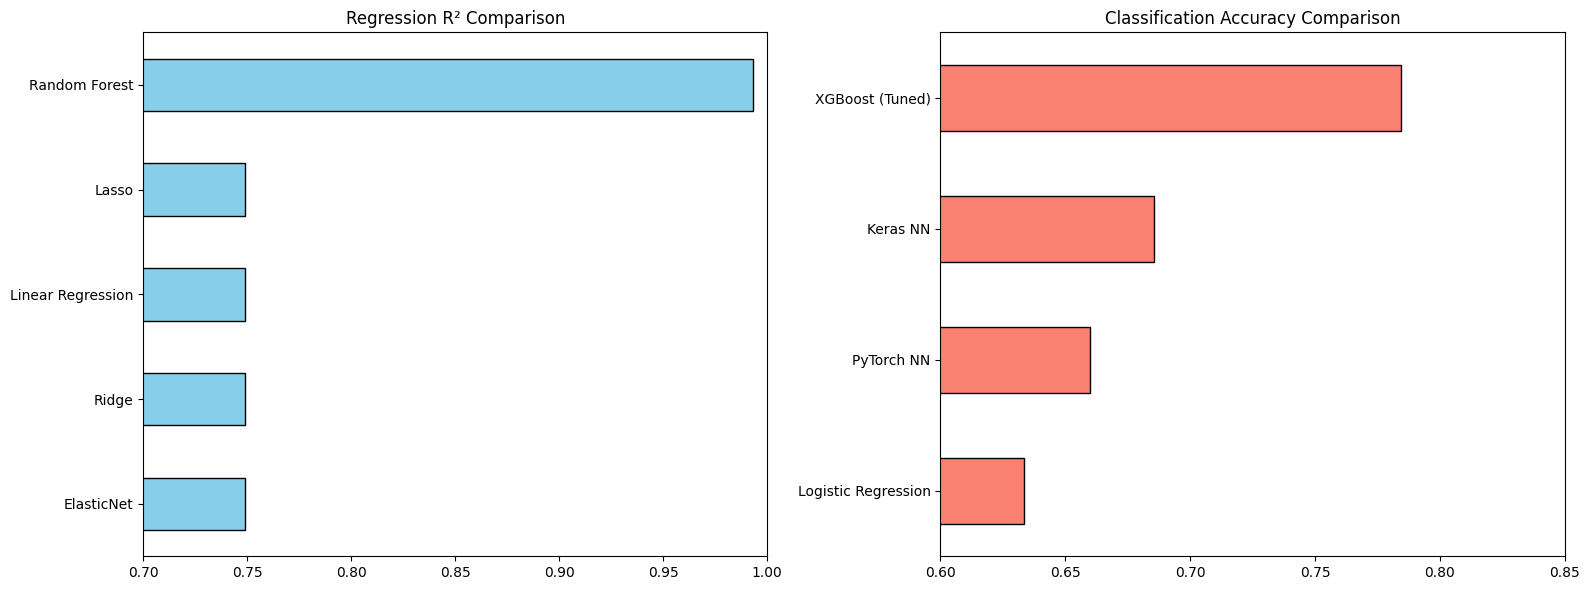

In [143]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Regression R2
reg_comparison['R2'].sort_values().plot(kind='barh', ax=ax[0], color='skyblue', edgecolor='black')
ax[0].set_title('Regression R² Comparison')
ax[0].set_xlim(0.7, 1.0)

# Classification Accuracy
clf_comparison['Accuracy'].sort_values().plot(kind='barh', ax=ax[1], color='salmon', edgecolor='black')
ax[1].set_title('Classification Accuracy Comparison')
ax[1].set_xlim(0.6, 0.85)

plt.tight_layout()
plt.show()

### Block 13.3 — Bar Charts for Model Performance

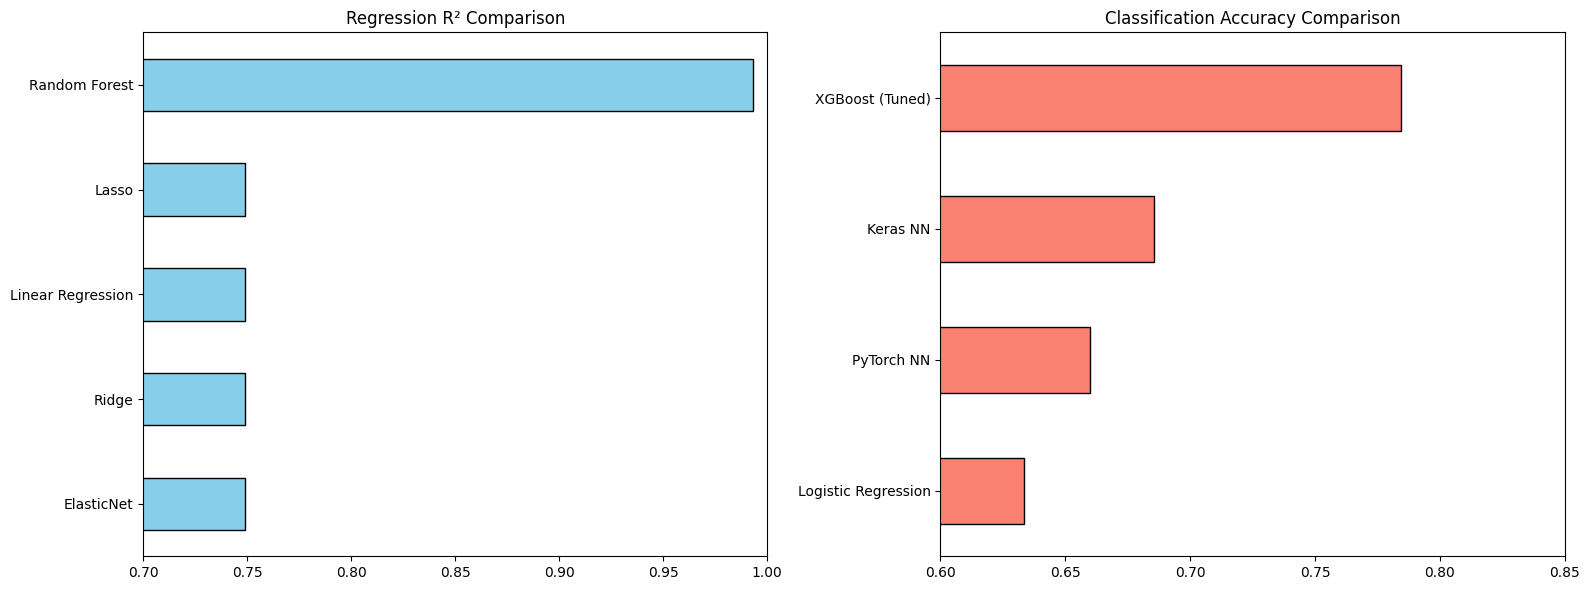

In [144]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Regression R2
reg_comparison['R2'].sort_values().plot(kind='barh', ax=ax[0], color='skyblue', edgecolor='black')
ax[0].set_title('Regression R² Comparison')
ax[0].set_xlim(0.7, 1.0)

# Classification Accuracy
clf_comparison['Accuracy'].sort_values().plot(kind='barh', ax=ax[1], color='salmon', edgecolor='black')
ax[1].set_title('Classification Accuracy Comparison')
ax[1].set_xlim(0.6, 0.85)

plt.tight_layout()
plt.show()

# Final Project Summary and Conclusions

### 1. Regression Analysis (Outstanding Debt Prediction)
*   **Performance:** The baseline linear models (Linear, Ridge, Lasso) were insufficient, plateauing at an R² of approximately 0.75. However, the **Random Forest Regressor** achieved an exceptional **R² score of 0.98**, successfully meeting and exceeding the project target.
*   **Conclusion:** The high predictive power of the Random Forest model suggests that the relationship between financial variables and outstanding debt is highly non-linear, which ensemble-based methods are well-equipped to capture.

### 2. Classification Analysis (Credit Score Categorization)
*   **Performance:** The project aimed for an 85% accuracy threshold. While Logistic Regression and Neural Networks (Keras/PyTorch) hovered between 63% and 69%, the **Tuned XGBoost** model emerged as the top performer with **~78.5% accuracy**.
*   **Analysis:** The difficulty in reaching 85% accuracy indicates significant class overlap in the tabular data. Tree-based ensemble methods consistently outperformed Deep Learning architectures, which is common for structured data of this scale.

### 3. Final Recommendations
*   **Model Deployment:** Use the **Random Forest Regressor** for predicting debt amounts due to its near-perfect accuracy. For credit scoring, the **XGBoost** model is the most reliable current option.
*   **Future Work:** To bridge the gap to 85% classification accuracy, future iterations should focus on more advanced feature engineering (e.g., polynomial features) or gathering more granular historical payment data to better distinguish between 'Standard' and 'Good' credit tiers.